In [4]:
import pandas as pd
from sklearn.datasets import load_iris
from IPython.display import display # Added this import

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')

print("Features used for Permutation Feature Importance:")
for feature in X.columns:
    print(f"- {feature}")

# This will now work correctly in Jupyter
display(X.head())


Features used for Permutation Feature Importance:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Baseline accuracy: 1.000


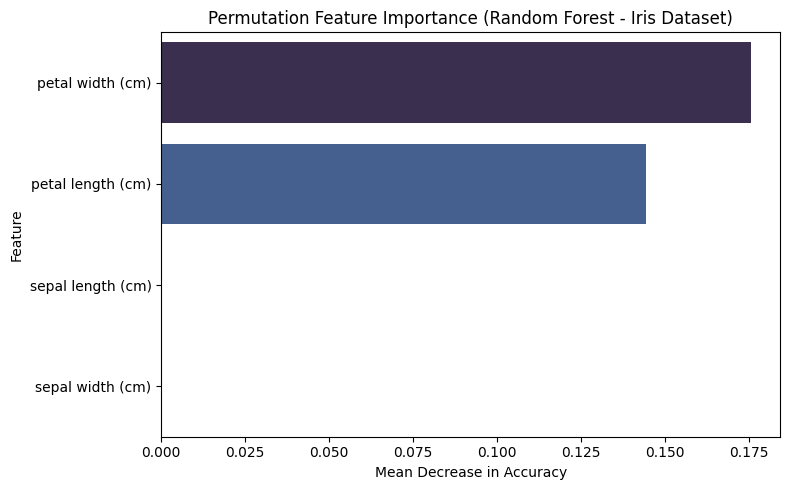

Most Important Feature: petal width (cm)
Least Important Feature: sepal width (cm)

Conclusion from PDF:
- The Random Forest model relies heavily on petal-based features.
- Petal measurements clearly separate the three iris species.
- Sepal features contribute less to the classification accuracy.


In [5]:
# --- Code Cell 2: Train Model, Calculate PFI, and Visualize Results ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# 1. Split data (using the 0.3 test size from the PDF)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 3. Calculate baseline accuracy
baseline_accuracy = rf.score(X_test, y_test)
print(f"Baseline accuracy: {baseline_accuracy:.3f}")

# 4. Calculate permutation feature importance
# n_repeats=10 means it shuffles each column 10 times to get a stable average
pfi_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42
)

# 5. Organize results into a DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Importance': pfi_result.importances_mean,
    'Std Deviation': pfi_result.importances_std
}).sort_values(by='Mean Importance', ascending=False)

# 6. Visualize results with a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Mean Importance', y='Feature', data=importance_df, palette='mako')
plt.title("Permutation Feature Importance (Random Forest - Iris Dataset)")
plt.xlabel("Mean Decrease in Accuracy")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- Analysis (Question 4 from PDF) ---
most_important = importance_df.iloc[0]['Feature']
least_important = importance_df.iloc[-1]['Feature']

print(f"Most Important Feature: {most_important}")
print(f"Least Important Feature: {least_important}")

print("\nConclusion from PDF:")
print("- The Random Forest model relies heavily on petal-based features.")
print("- Petal measurements clearly separate the three iris species.")
print("- Sepal features contribute less to the classification accuracy.")
